In [5]:
import pandas as pd

# Load dataset
data = pd.read_csv(r"C:\Users\Jainy\Documents\-B-13-PrognosAI-AI-Driven-Predictive-Maintenance-System\dataset\train_FD001.txt", sep=r"\s+", header=None)

data.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
cols = ['unit_id','cycle','op1','op2','op3']

sensor_cols = [f'sensor{i}' for i in range(1,22)]

data.columns = cols + sensor_cols

In [7]:
rul = data.groupby('unit_id')['cycle'].max().reset_index()
rul.columns = ['unit_id','max_cycle']

data = data.merge(rul,on='unit_id')

data['RUL'] = data['max_cycle'] - data['cycle']

data.drop('max_cycle',axis=1,inplace=True)

In [8]:
X = data.drop(['unit_id','cycle','RUL'],axis=1)
y = data['RUL']

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("RMSE:",rmse)
print("MAE:",mae)
print("R2:",r2)

RMSE: 41.368609922845984
MAE: 29.890275985349827
R2: 0.625423806441504


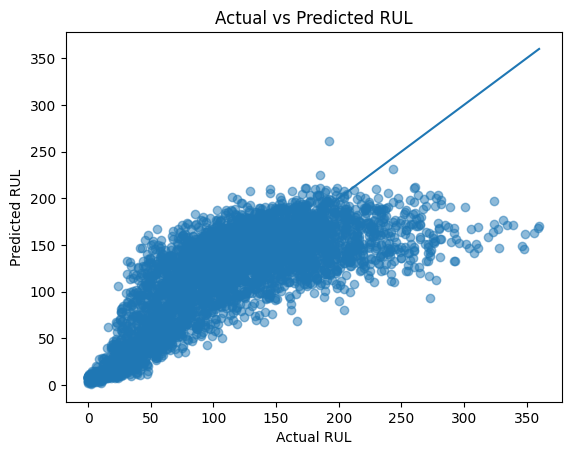

In [12]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test,y_pred,alpha=0.5)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")

plt.title("Actual vs Predicted RUL")

plt.plot([min(y_test),max(y_test)],
         [min(y_test),max(y_test)])

plt.show()

In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    scoring="neg_mean_squared_error",
    cv=5
)

rmse_scores = np.sqrt(-scores)

print("RMSE scores:",rmse_scores)
print("Mean RMSE:",rmse_scores.mean())
print("Std Dev:",rmse_scores.std())

RMSE scores: [35.41032504 34.96262227 38.01074602 52.16320802 51.72002231]
Mean RMSE: 42.45338473068764
Std Dev: 7.817985559453357


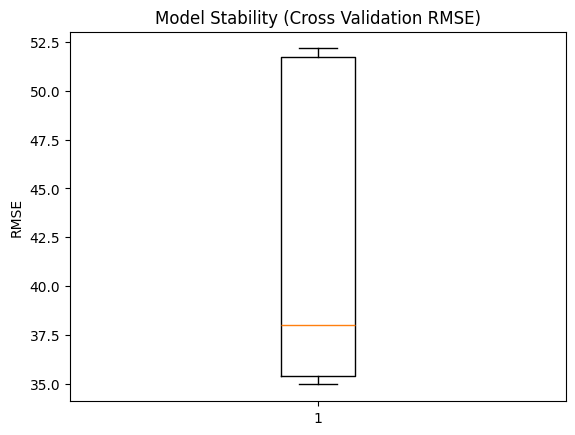

In [14]:
plt.boxplot(rmse_scores)

plt.title("Model Stability (Cross Validation RMSE)")

plt.ylabel("RMSE")

plt.show()